In [1]:
from panco.descriptor.curves import TokenBucket, RateLatency, sum_ac
from panco.descriptor.flow import Flow
from panco.descriptor.server import Server
from panco.descriptor.network import Network
from panco.fifoCplex.admTFA import AdmTfaCpx
from panco.fifoCplex.fifoLP import FifoLPCpx
from panco.fifoCplex.sfaLP import SfaLPCpx
import matplotlib.pyplot as plt

import time
import numpy as np
import pandas as pd

## Comparison of methods

- Worst-case delay bounds and runtimes using  the Panco toolbox, with the Cplex solver;
- the LUDB bounds and runtimes with Deborah [1];
- Worst-case delay bounds that optimizes the LUDB analysis, by searching  an optimal decomposition of the network into tandem networks. 

This notebook, makes no computation,and is only here for comparing the performance of the methods. 
The code for running the Panco method there, and the other results are taken from the papers [2, 3], and their associated date that are freely available data through the links [4, 5] ([4] for the dataaset, and [5] for the run times. 

The networks are givenby means of java files that first need to be download so tht thy can be mapped to the Panco framework. Them, the csv files, that store for each network and flow its delay bounds, and computation times. We only compute the statistic performance (average runtime and worst-case delay. A per flow comparison may not be accurate, since corner-cases have been exhibited in the Deborah implementation [6]. 

Regarding the runtimes, this means that the  Panco implementation and others are run on different machines. They have approximaltely the same computing capabilities in term of CPU, so may be quite accurate, although not very precise. 

[1] https://github.com/rzippo/deborah

[2] Alexander Scheffler, Jens B. Schmitt, Steffen Bondorf: Searching for Upper Delay Bounds in FIFO Multiplexing Feedforward Networks. RTNS 2022: 230-241

[3] Lukas Herll, Steffen Bondorf: Non-linear Programming for the Network Calculus Analysis of FIFO Feedforward Networks. ICPE 2025: 266-279

[4] https://github.com/alexscheffler/dataset-rtns2022

[5] https://github.com/Lukasssssssssss/ICPE2025-Non-linear-Programming-for-the-Network-Calculus-Analysis-of-FIFO-Feedforward-Networks

[6] https://github.com/rzippo/deborah/tree/master/scenarios/edge-cases

We first upload the performance with the Cplex algorithm (`perf_cplex`). Thfis file can also be generated from the notebook `cplex_networks`

In [7]:
import pickle

file =  open('perf_cplex', 'rb')
[tab_sfa, tab_plp, tab_elp,  tab_time_sfa, tab_time_plp, tab_time_elp] = pickle.load(file)

file =  open('networks', 'rb')
tab_networks = pickle.load(file)

We use the files available for the results in paper [3] and compute the total running time per network (in hours)

In [8]:
filename = "ICPE25/data/DiffLUDB_100_0_false_runtime.csv"
f= open(filename)
data = pd.read_csv(filename)
new_runtime = data.groupby(['Netid']).sum()/(1e9 * 3600)
# new_data[' LUDB_FF'] = new_data[" LUDB_FF"]
list_lubd_runtimes = list(new_runtime["DiffLUDB"])
list_lubd_runtimes



[2.872900861111111e-05,
 0.00024398502944444444,
 0.03562148847694444,
 5.56806375e-05,
 0.0005174407836111111,
 2.6045333333333335e-07,
 0.036909627993055555,
 0.004299733303888889,
 0.03140894501805556,
 5.444761111111111e-07,
 0.04855543307777778,
 0.017394622115555557,
 2.926318388888889e-05,
 0.0007255501863888889,
 4.9925638055555555e-05,
 0.06479936618583333,
 0.11905782706722222,
 0.01324349990388889,
 2.111921388888889e-06,
 7.630138888888889e-08,
 9.308572222222223e-07,
 0.015951408765,
 0.0009065118255555556,
 0.44263300553,
 0.23322220221416667,
 0.0017396078647222222,
 0.005279775885277778,
 0.0016175533086111111,
 0.0204065047625,
 3.2478598055555555e-05,
 0.004874286588888889]

Running times for each network (in hour) with LUDB-FF (base for the comparison of delays with LUDB-NLP) of RTNS22 [3]

In [24]:
filename = "dataset-rtns2022-main/data/LUDB_FF_runtime.csv"
f= open(filename)
data = pd.read_csv(filename)
new_runtime_ludb = data.groupby(['Netid']).sum()/(1e9 * 3600)
list_lubd_runtimes_ludb = list(new_runtime_ludb[" LUDB_FF"])


Per server running times for Cplex (in hours)

In [29]:

n_f = sum(net.num_flows for net in tab_networks)
time_plp = [sum(t)/3600 for t in tab_time_plp]

time_plp
time_eplp = [sum(t)/3600 for t in tab_time_elp]
mean_time_plp = sum(time_plp)/(n_f)
mean_time_plp


0.00020814462255276482

In [30]:
print(time_plp)

[9.1412001185947e-05, 0.00020747039053175184, 0.011218896243307325, 9.808507230546739e-05, 0.00018904560142093233, 2.1534959475199382e-05, 0.014691406554645962, 0.00047742446263631186, 0.046591985093222724, 6.0923231972588436e-05, 0.004684002863036262, 0.016841960880491468, 0.0001782994137869941, 0.0008498550123638577, 0.00017139256000518798, 0.011372170117166307, 0.01043536384900411, 0.002686209612422519, 7.32278823852539e-05, 3.0772023730807835e-05, 6.990253925323486e-05, 0.028254665003882514, 0.0014630203114615547, 0.6024004817008972, 0.16116037355528937, 0.004937669701046414, 0.0015561915768517389, 0.0015370973613527087, 0.008542896972762214, 8.535232808854845e-05, 0.0013006755378511218]


## Comparisons

### Running times

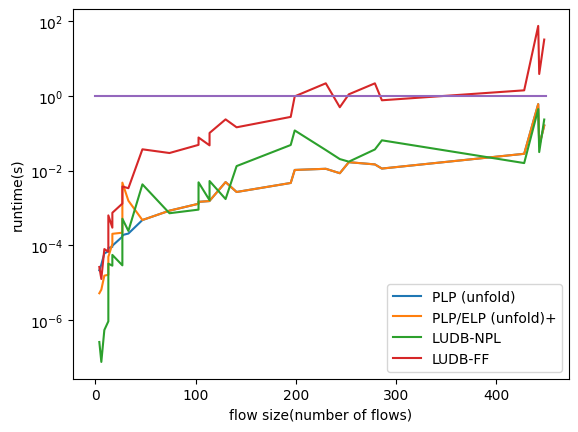

In [28]:
tab_len = [tab_networks[i].num_flows for i in range(31)]
tt_ludb = [list_lubd_runtimes[i] for i in range(31)]
tt_lu = [(tab_len[i], tt_ludb[i]) for i in range(31)] 
tt_p = [(tab_len[i], time_plp[i]) for i in range(31)]
tt_pe = [(tab_len[i], time_eplp[i]) for i in range(31)]
tt_ludb_e = [(tab_len[i], list_lubd_runtimes_ludb[i]) for i in range(31)]
tt_p.sort()
tt_lu.sort()
tt_ludb_e.sort()
tt_pe.sort()
t_x = [a for (a,b) in tt_p]
t_p = [b for (a,b) in tt_p]
t_pe = [b for (a,b) in tt_pe]
t_u = [b for (a, b) in tt_lu]
t_ue = [b for (a, b) in tt_ludb_e]

plt.plot(t_x, t_p, label="PLP (unfold)")
plt.plot(t_x, t_pe, label="PLP/ELP (unfold)+")

plt.plot(t_x, t_u, label="LUDB-NPL ")
plt.plot(t_x, t_ue, label="LUDB-FF")
plt.plot([0, 450], [1, 1])
plt.semilogy()
plt.xlabel('flow size(number of flows)')
plt.ylabel('runtime(s)')
plt.legend()
plt.show()

### Delay bounds

We first compute the average delay per network for the LUDB method (the best known, from RTNS22[3])

In [58]:
filename = "dataset-rtns2022-main/data/LUDB_FF_delay.csv"
f= open(filename)
data = pd.read_csv(filename)
new_data = data.groupby(['Netid']).mean()

new_data

,Fid,LUDB_FF
Netid,,
1,8.0,1.320903
2,16.0,2.632592
3,114.5,6.958322
5,8.0,1.534967
6,13.0,2.162244
7,1.5,1.212119
8,139.0,7.991318
9,23.0,2.943985
10,221.0,6.648767


In [55]:
num_net = 31
list_lubd_delays = list(new_data[" LUDB_FF"])
list_small_lubd_delays = [list_lubd_delays[i] for i in range(num_net)]

Extraction from the Cplex computations

In [48]:
print([np.mean(tab_elp[i]) for i in range(31)])

[np.float64(1.1994035702156698), np.float64(1.9751748206806827), np.float64(5.0818806119375415), np.float64(1.3781800085110893), np.float64(1.6087302850323955), np.float64(1.1990999641669386), np.float64(4.946176261160412), np.float64(2.0384866675839897), np.float64(5.076832296555871), np.float64(1.2119149033252792), np.float64(3.0374438303933786), np.float64(4.459676062670624), np.float64(1.695204254240517), np.float64(3.2913491904831695), np.float64(1.630965751100012), np.float64(3.517087679479756), np.float64(4.5175301414875015), np.float64(3.2084174884163894), np.float64(1.4021872373440851), np.float64(0.8996143685156759), np.float64(1.1038519086795184), np.float64(4.3802210241730455), np.float64(2.9573508904074144), np.float64(5.170342256569614), np.float64(5.208340102027951), np.float64(4.104658456663654), np.float64(3.1989328444435783), np.float64(2.846997490448681), np.float64(3.888810111068134), np.float64(1.2679666104308778), np.float64(3.025244684859244)]


In [41]:
tab_len = 31
tab_pair = [(tab_networks[i].num_flows, np.mean(tab_sfa[i])) for i in range(tab_len)]

In [49]:
[(i, np.mean(list_small_lubd_delays[i]), np.mean(tab_plp[i]), np.mean(tab_elp[i])) for i in range(tab_len)]

[(0,
  np.float64(1.320902555134755),
  np.float64(1.3022623774606803),
  np.float64(1.1994035702156698)),
 (1,
  np.float64(2.632592459416915),
  np.float64(2.31859362559796),
  np.float64(1.9751748206806827)),
 (2,
  np.float64(6.958322264931692),
  np.float64(5.0818806119375415),
  np.float64(5.0818806119375415)),
 (3,
  np.float64(1.5349673528567511),
  np.float64(1.4414750539106798),
  np.float64(1.3781800085110893)),
 (4,
  np.float64(2.1622435544787515),
  np.float64(1.8584492773209003),
  np.float64(1.6087302850323955)),
 (5,
  np.float64(1.212118748161594),
  np.float64(1.2389643622651403),
  np.float64(1.1990999641669386)),
 (6,
  np.float64(7.99131820986793),
  np.float64(4.946176261160412),
  np.float64(4.946176261160412)),
 (7,
  np.float64(2.9439845317968554),
  np.float64(2.0384866675839897),
  np.float64(2.0384866675839897)),
 (8,
  np.float64(6.648766922465732),
  np.float64(5.076832296555871),
  np.float64(5.076832296555871)),
 (9,
  np.float64(1.29669586573342),
  np

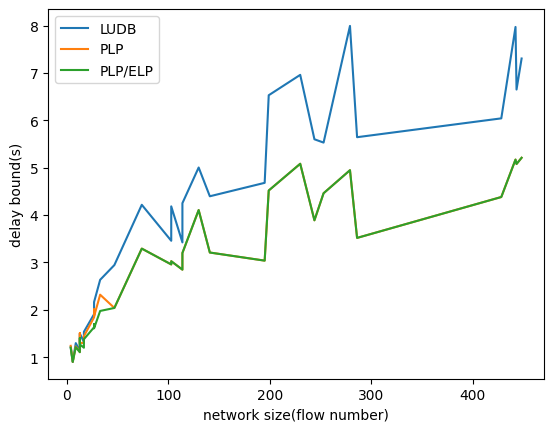

In [52]:
tab_len = [tab_networks[i].num_flows for i in range(num_net)]
tab_pair1 = [(tab_len[i], list_small_lubd_delays[i], np.mean(tab_plp[i]), np.mean(tab_elp[i])) # , np.mean(tab_heu[i]))#, 
              #np.mean(tab_mod[i]))
             for i in range(len(tab_len))]


tab_pair1.sort()
t_x = [a for (a, b, c, d) in tab_pair1]
t_y = [b for (a, b, c, d) in tab_pair1]
t_z = [c for (a, b, c, d) in tab_pair1]
t_w = [d for (a, b, c, d) in tab_pair1]
# t_a = [d for (a, b, c, d, e) in tab_pair1]
#t_e = [e for (a, b, c, d) in tab_pair1]
t_r1 = [(b -d)/d for (a, b, c, d) in tab_pair1]
t_r2 = [(b -c)/c for (a, b, c, d) in tab_pair1]
plt.plot(t_x, t_y, label='LUDB')
# plt.plot(t_x, t_a, label='heu')
#plt.plot(t_x, t_e, label='mod')
plt.plot(t_x, t_z, label='PLP')
plt.plot(t_x, t_w, label='PLP/ELP')
#plt.plot(range(len(t_x)), t_z, label='LUDB')
# plt.semilogy()
plt.ylabel('delay bound(s)')
plt.xlabel('network size(flow number)')
# plt.xlim([0, 50])
plt.legend()
plt.show()

### Pessimism

(ludb - plp)/plp

and

(ludb - elp)/plp

In [56]:
print("average pessimism = ", np.mean(t_r1))

average pessimism =  0.2880480569897915


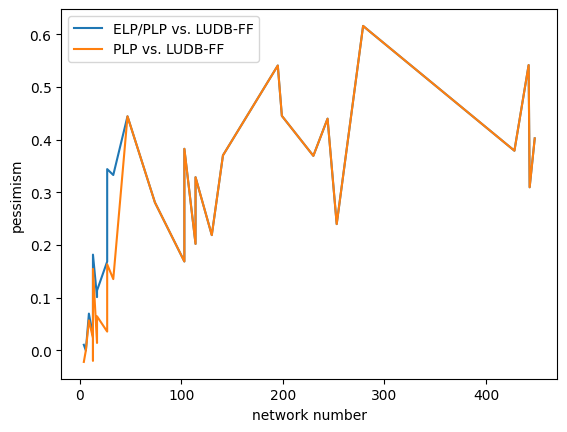

In [57]:
plt.plot(t_x, t_r1, label="ELP/PLP vs. LUDB-FF")
plt.plot(t_x, t_r2, label="PLP vs. LUDB-FF")
plt.xlabel("network number")
plt.ylabel("pessimism")
plt.legend()
plt.show()